
<p style="font-size:1.25em;"> Ce notebook a pour objectif de fournir rapidement : <br> <strong> Le paramètre d’ordre nématique moyen</strong> <strong>
et les pics de corrélation</strong> à partir d’un dossier contenant des fichiers <strong>H5</strong>. </p>

<span style="font-size: 1.4em; font-weight: 700;"> Fonctionnalités principales</span>
<p style="font-size:1.15em;">

Calcul des intensités moyennes du dossier

Extraction des pics de corrélation

Détermination du paramètre d’ordre sur la valeur de q du premier pic

Importation de l'image de diffusion moyenne,
avec tracé automatique des cercles correspondant aux différents pics

</p>


In [15]:
print("djk")


%matplotlib widget
from utilities_SWING import *
import pandas as pd
from saxsprocessor import SAXSProcessor
import glob
import os
import numpy as np
from matplotlib import pyplot as plt
import re
from utilities_SWING import *
import pandas as pd
from filereaders import h5File_SWING
from utilities import *
from pathlib import Path

# Make pyfai warning silent (optional, but nicer output)
import logging, warnings

logging.getLogger("pyFAI").setLevel(logging.ERROR)
logging.getLogger("fabio").setLevel(logging.ERROR)

warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide",
    module="pyFAI"
)

djk


**Definition of path, mask file, and output directory (optional)**

In [16]:
path =  'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/Run_synchrotron_SOLEIL_02_2026_suivi_manips_after_run.xlsm' # Attention important pour stock
mask = 'mask_pyfai.edf'
instrument='SWING'
output_dir='./test_output/'
os.makedirs(output_dir,exist_ok=True)

##### **Change the format of the mask: from txt to edf (already done)**

### **Make an instance of the SAXSProcessor class**

 **New feature: find automatically the beackground reference file and the form factor parameters: diameter, length, polydispersity of both [%]**


It is now possible to use **get_all_params()** from the module **excel_parameters_extractor** to find :
- the reference background file that will be used when creating the instance of the module **SAXSProcessor()**
- the geometric parameters (d,L, polydisp) that will be used in **compute_nematic_parameter()**



Parameters:

- *excel_file* : (str)
    Path to the excel file.
- *bg_path* : (str)
    Path to the folder containing the reference files.
- *h5path* : (str)
    Path to the folder containing the h5 files.

Returns:

- *diameter*: (float)
    Diameter in nm.
- *length*: (float)
    Length in nm.
- *polydispersity_d*: (float)
    Polydispersity of the diameter in [%].
- *polydispersity_L*: (float)
    Polydispersity of the length in [%].
- *reference_file*: (str)
    Path of the reference file.

*Notes: the excel file must contain the indexes of the h5 files, for example: for files lacroix_00782_2024-07-20_02-32-08.h5, the index they must be written as "00782" in the "FILE" column of the excel.* 

In [17]:
from excel_parameters_extractor import get_all_params

excel_file = "C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/Run_synchrotron_SOLEIL_02_2026_suivi_manips.xlsm" # path to the excel file containing the parameters 
bg_path = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/' # path of the folder containing the background files (probably the same as the folder containing the h5 files)
fileh5 = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/lacroix_00426_2026-02-08_08-59-49.nxs'
#fileh5 = 'test_data/SWING_fev2026/example_emma_rods/test/lacroix_00186_2026-02-06_15-50-57.nxs' # your path to the h5 file you want to analyze


diameter, polydispersity_d, length, polydispersity_L, B, reference_file  = get_all_params(excel_file, bg_path, fileh5) # here specify the measurement name

print("Extracted parameters from excel:")
print(f"Diameter: {diameter} nm")
print(f"Polydispersity on diameter: {polydispersity_d} %")
print(f"Length: {length} nm")
print(f"Polydispersity on length: {polydispersity_L} %")
print(f"Magnetic feild value: {B} mT")
print(f"Reference file: {reference_file}") 



Measurement name found: M0363 for index of h5 file 426.0
Extracted parameters from excel:
Diameter: 23.6 nm
Polydispersity on diameter: 15.677966101694915 %
Length: 23.6 nm
Polydispersity on length: 15.68 %
Magnetic feild value: 700 mT
Reference file: C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/lacroix_00148_2026-02-06_06-55-44.nxs


c:\Users\lisab\anaconda3\envs\saxs\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\lisab\anaconda3\envs\saxs\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [18]:
import h5py
with h5py.File(fileh5,"r") as f:
    f.visit(print)

S0006_M0363_00426
S0006_M0363_00426/SWING
S0006_M0363_00426/SWING/EIGER-4M
S0006_M0363_00426/SWING/EIGER-4M/bias
S0006_M0363_00426/SWING/EIGER-4M/binning_x
S0006_M0363_00426/SWING/EIGER-4M/binning_y
S0006_M0363_00426/SWING/EIGER-4M/controller_record
S0006_M0363_00426/SWING/EIGER-4M/delta0
S0006_M0363_00426/SWING/EIGER-4M/detector_based_uncertainty
S0006_M0363_00426/SWING/EIGER-4M/dir_beam_x
S0006_M0363_00426/SWING/EIGER-4M/dir_beam_z
S0006_M0363_00426/SWING/EIGER-4M/distance
S0006_M0363_00426/SWING/EIGER-4M/exposure_time
S0006_M0363_00426/SWING/EIGER-4M/gain_ph_per_ADU
S0006_M0363_00426/SWING/EIGER-4M/gamma0
S0006_M0363_00426/SWING/EIGER-4M/gap_time
S0006_M0363_00426/SWING/EIGER-4M/nb_frames
S0006_M0363_00426/SWING/EIGER-4M/pixel_size_x
S0006_M0363_00426/SWING/EIGER-4M/pixel_size_z
S0006_M0363_00426/SWING/EIGER-4M/shutter_close_delay
S0006_M0363_00426/SWING/EIGER-4M/type
S0006_M0363_00426/SWING/ans-c11__ei__c-u20
S0006_M0363_00426/SWING/ans-c11__ei__c-u20/gap
S0006_M0363_00426/SWING/an

In [19]:
# If no reference file, you can set reference_file to None:
#proc = SAXSProcessor(instrument=instrument ,file=fileh5, mask=mask) 

# If you have the reference file extracted from the previous function, use it to automatically subtract the background:
proc = SAXSProcessor(instrument=instrument,reference_file=reference_file ,autosubstract=True,file=fileh5, mask=mask)

position moteur :
{'X_start': array([36.4999]), 'X_end': array([38.2498]), 'Z_start': array([39.8993]), 'Z_end': array([40.4495])}
{'X_start': array([36.4999]), 'X_end': array([38.2498]), 'Z_start': array([39.8993]), 'Z_end': array([40.4495])}
step :
[0.04860833]
[0.04585]
1
Raw data shape: (36, 12, 1083, 1035)
info
1083
1035
position moteur :
{'X_start': array([36.4998]), 'X_end': array([38.6997]), 'Z_start': array([39.4997]), 'Z_end': array([40.9])}
{'X_start': array([36.4998]), 'X_end': array([38.6997]), 'Z_start': array([39.4997]), 'Z_end': array([40.9])}
step :
[0.183325]
[0.1750375]
1
Raw data shape: (12, 8, 1083, 1035)
info
1083
1035
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Optimized k factor for reference subtraction: 0.0387002
(1083, 1035)


**Plot transmission map**

In [20]:

#plot_transmission_map_from_singleh5(fileh5, proc)

**Plot average SAXS image**

✅ SAXS image saved: C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/saxs_images/S0006_M0363_Img_426.png


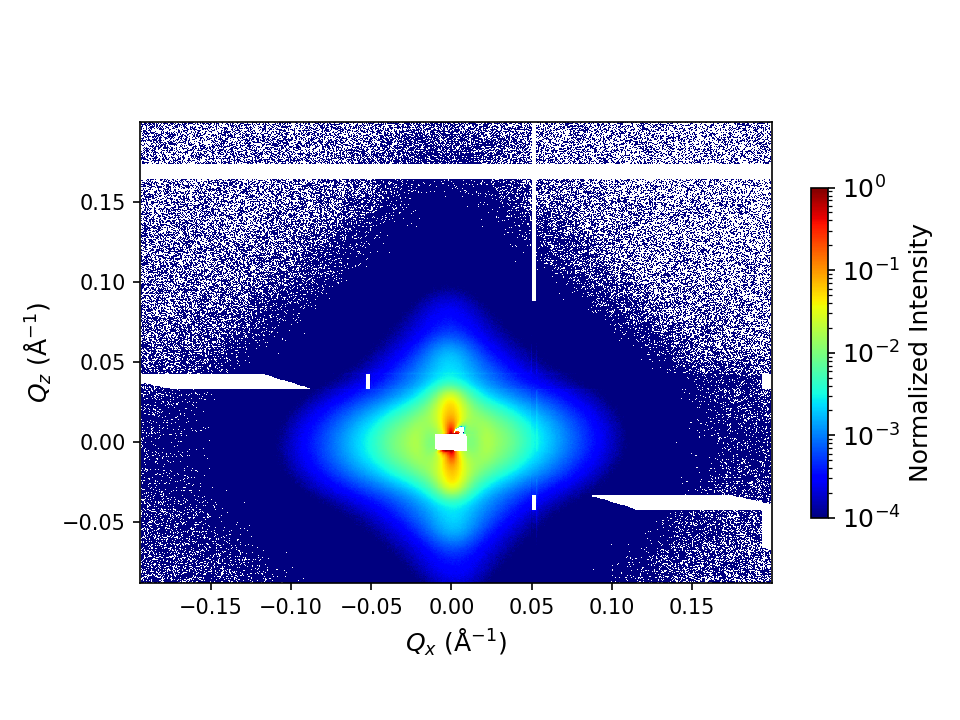

In [21]:
# Use dedicated function to plot average SAXS image
proc.plot2d_vsq()

**Plot and save average radial profile**

From the image above, we can define a q range of interest. This q range can also be determined by plotting the radial profile.
Let's do this first.
Note that the knowledge of this q range is critical for the determination of correlation distances, as it strongly affects results

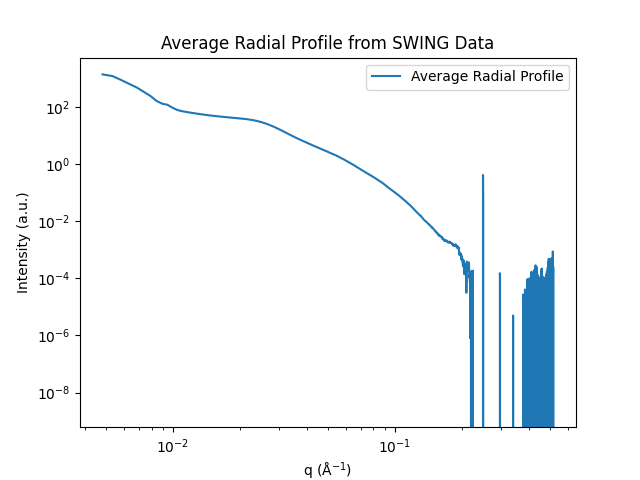

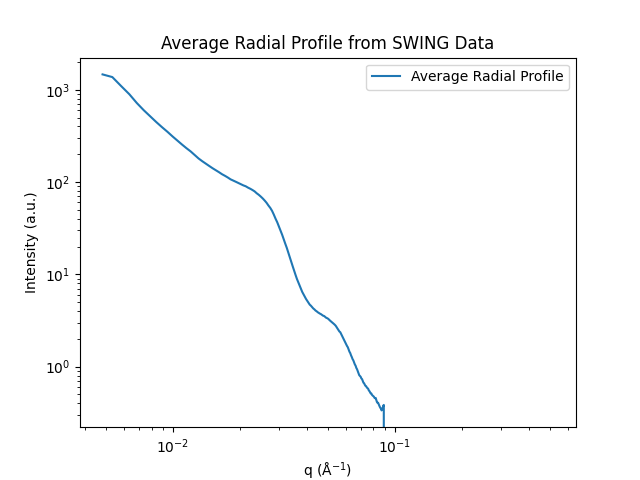

In [22]:
# Plot radial profile for average data
output_dir = os.path.join(proc.path,'average_radial_profile')
q,Ir = proc.extract_radial_profile(azimuth=0, width=360,output_dir=output_dir)
q1,Ir1 = proc.extract_radial_profile(azimuth=90, width=10,output_dir=output_dir)
np.savetxt(r"C:\Users\lisab\aSAXS\Synchrotron\donnesnxs\integrations\qi.dat", np.column_stack((q, Ir)))    
    

plt.figure()
plt.loglog(q, Ir, label='Average Radial Profile')
plt.xlabel('q (Å$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Average Radial Profile from SWING Data')
plt.legend()
plt.figure()
plt.loglog(q1, Ir1, label='Average Radial Profile')
plt.xlabel('q (Å$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Average Radial Profile from SWING Data')
plt.legend()

## Determination of correlation peak

**Knowledge of working q range**

The algorithm for the determination of correlation peak requires the knowledge of workin q range (between qmin and qmax). If qmax is not set,the algorithm may focus on the noisy high q range signal. qmax=0.15 may be a good option. Alos qmin should be considered with care. The user is allowed to play with the algorithm parameters until satisfactory results are obtained.

**Hybrid Method**

Here we use a hybrid method using advantages of 2 methods:
- 2nd derivative method is used to identify peak positions (fast and efficient)
- each peak is refined using Split Pseudo Voigt functions to ensure accurate determination of correlation distance (peak identification with this method is not optimum)

There is a large number of arguments in the function. The most relevants are the followings:
- qmin and qmax defining the q window
- nb_peaks defining the number of peaks to search in the specified q window
- method = 'hybrid', 'spv', or 'derivative' depending on the method selected for the computation
- substract_power_law (bool)
- fit_window_width


Playing with these parameters should be enough to obtain satisafctory results. In cas of issues, read dedicated documentation (file parameter_guide.py).


In [26]:
get_results = detect_peaks_hybrid_interactive(
    proc,
    nb_peaks_init=3,
    qmin_init=0.01,
    qmax_init=0.15,
    fit_window_width_init=1,
    prominence=0.8,
    distance_pts=20,
    azimuth=0,
    width=10,
    batch = False)




Output()

In [120]:

# Après avoir ajusté les sliders, récupérer les résultats
results_dict = get_results()
distances = results_dict['distances']
distances_std = results_dict['distances_std']
hybrid_results = results_dict['hybrid_results']
peaklist = results_dict['peaklist']
q_min = results_dict['qmin']
q_max = results_dict['qmax']
nb_peaks = results_dict['nombredepics']


# Permet d'enregister les bons paramêtres pour les réutiliser en batch (ne semble pas utile car on a pas vraiment besoin d'ajuster les parametres)
results={
    'samplename': proc.samplename,
    'qmin' : q_min,
    'qmax' : q_max,
    'nb_peaks' : nb_peaks
}

# add dictionary to existing csv or create new one
csv_file = os.path.join(path,'parametres_batch.csv') 
if os.path.exists(csv_file):
    df_existing = pd.read_csv(csv_file)
    df_new = pd.DataFrame([results])
    df_combined = pd.concat([df_existing, df_new], ignore_index=True)
    df_combined.to_csv(csv_file, index=False)
    # visualize added line
    print(df_new)
else:
    df = pd.DataFrame([results])
    df.to_csv(csv_file, index=False)



    samplename   qmin  qmax  nb_peaks
0  S0014_M0260  0.025  0.11         2


## Nematic order parameter

**Selection of working qvalue**

We select the first pealk returned by the calculation of correlation distances

In [121]:
qvalues = peaklist
# If you didn't use the function to extract parameters from excel (get_all_params), you can directly set your parameters here:
# L = 1000
# radius = 100 
# radius_pd = 0.2
# L_pd=1.7  # polydispersity on length is huge!


# If you did use the function to extract parameters from excel (get_all_params), you can use the extracted parameters here:
L = length * 10  # convert nm to Å
radius = diameter * 10 / 2  # convert nm to Å
radius_pd = polydispersity_d * 0.01 # convert percent to fraction
L_pd = polydispersity_L * 0.01 # convert percent to fraction

**Form factor parameters**

**Form factor parameters**

Used for nematic order calculation

Either define it yourself, or you can use the parameters extracted from the excel file.

**Nematic Order Calculation**

It is computed for the first peak



Azimuthal profile completeness check:
  Status: INCOMPLETE
  Found 30 gap(s) with invalid data:
    Gap 1: between χ=-177.0° and χ=-176.3° (1 points)
    Gap 2: between χ=-166.3° and χ=-165.7° (1 points)
    Gap 3: between χ=-150.3° and χ=-149.7° (1 points)
    Gap 4: between χ=-108.3° and χ=-107.7° (1 points)
    Gap 5: between χ=-105.7° and χ=-105.0° (1 points)
    Gap 6: between χ=-102.3° and χ=-101.7° (1 points)
    Gap 7: between χ=-99.0° and χ=-98.3° (1 points)
    Gap 8: between χ=-95.0° and χ=-94.4° (1 points)
    Gap 9: between χ=-91.7° and χ=-91.0° (1 points)
    Gap 10: between χ=-87.7° and χ=-87.0° (1 points)
    Gap 11: between χ=-83.7° and χ=-83.0° (1 points)
    Gap 12: between χ=-68.4° and χ=-67.7° (1 points)
    Gap 13: between χ=-29.0° and χ=-28.4° (1 points)
    Gap 14: between χ=-21.0° and χ=-20.4° (1 points)
    Gap 15: between χ=-7.7° and χ=-7.1° (1 points)
    Gap 16: between χ=-4.4° and χ=-3.7° (1 points)
    Gap 17: between χ=-0.4° and χ=0.3° (1 points)
    Ga

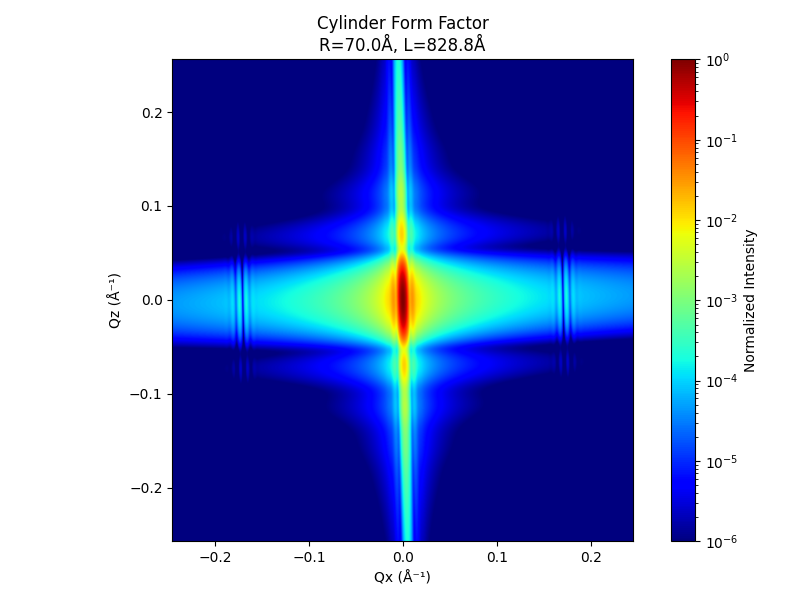


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in T:/LPCNO/NCO/Manips/DATA_SAXS/SWING_align_fev26/20250369/2026/Run1/lacroix/s0014\azimuthal_profiles\S0014_M0260_B=0_Img322_nematic_determination.png

Fitting results:
x0: 89.45579478440254
S: 0.9914201834411449
R2: 0.9949052855022101


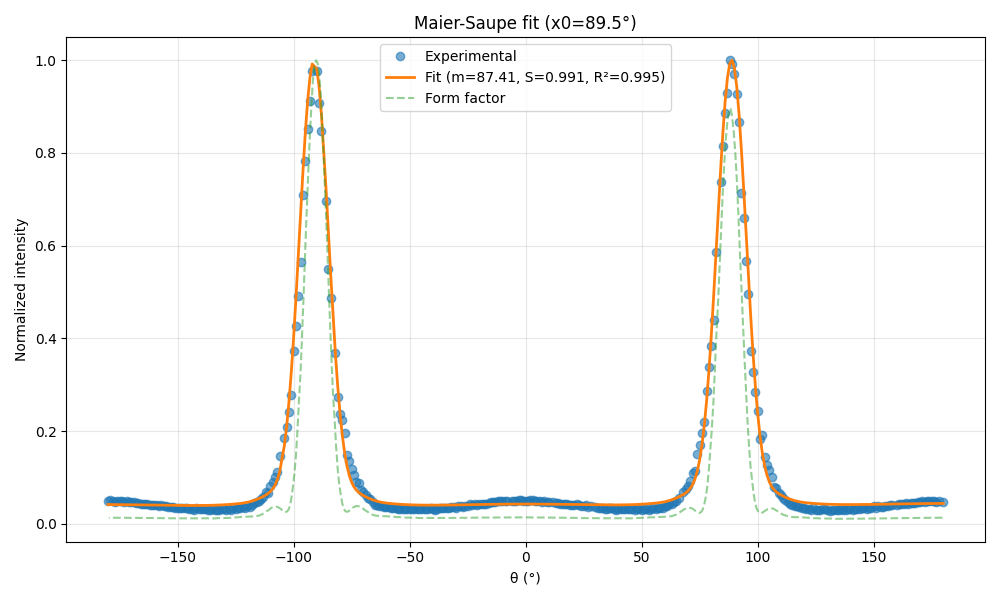

In [122]:
threshold = 0.01
plot = True
apply_mirror = False 
verbose = False

#calcul de S pour tous les pics
'''
S_array = np.zeros(len(qvalues))
for i, qvalue in enumerate(qvalues):
    S, mean_angle, dict = compute_nematic_parameter(
        processor = proc,
        qvalue = qvalue, 
        threshold = threshold,
        radius = radius,
        L = L,
        radius_pd = radius_pd,
        L_pd= L_pd,
        plot = plot,
        verbose = True
        )
    S_array[i] = S'''

#calcul de S le premier pic

S, mean_angle, dict = compute_nematic_parameter(
        processor = proc,
        qvalue = peaklist[0], 
        threshold = threshold,
        radius = radius,
        L = L,
        radius_pd = radius_pd,
        L_pd= L_pd,
        plot = plot,
        verbose = True
        )





## Store results in a dict or csv???

**Metadata**

Dans les exemple de data SWING à notre disposition, on ne fait pas varier le champ magnétique.

J'ai ajouté à la classe h5File_Swing une méthode pour extraire la valeur de B de l'attribut samplename.

Lors de l'acquisition des data, au moment de remplir le champ de référence échantillon, il vous faudra ajouter le champ B à la réf échantillon sous un format de style **'*_xxxmT*'**. 
 
 A la lecture du fichier h5, on aura alors accès à la valeur de B via l'attribut B de SAXSProcessor.

**Stockage csv**

J'ai ici indiqué un chemin vers un fichier csv fictif. A modifier


In [123]:
# save data in dictionary

results={
    'samplename': proc.samplename,
    'B (mT)': B, # given by the excel parameters extractor function
    'peaks' : peaklist,
    'distance (A)': distances[0], # array of distances # array of errors parameters
    'mean_orientation': mean_angle,
    'nematic order' : S
}

# add dictionary to existing csv or create new one
csv_file = os.path.join(path,'analysis_results.csv') 
if os.path.exists(csv_file):
    df_existing = pd.read_csv(csv_file)
    df_new = pd.DataFrame([results])
    df_combined = pd.concat([df_existing, df_new], ignore_index=True)
    df_combined.to_csv(csv_file, index=False)
    # visualize added line
    print(df_new)
else:
    df = pd.DataFrame([results])
    df.to_csv(csv_file, index=False)


    samplename  B (mT)                                        peaks  \
0  S0014_M0260     700  [0.033584525420373317, 0.06698347577740603]   

   distance (A)  mean_orientation  nematic order  
0    187.085726          1.089574        0.99142  


## Cartographie 

In [24]:


testfile = Path(fileh5)
edfpath = testfile.parent / "cartographie" / testfile.stem
edfpath.mkdir(parents=True, exist_ok=True)
edfpath = str(edfpath)

reference = Path(reference_file)
edfpathr = reference.parent / "cartographie" / reference.stem
edfpathr.mkdir(parents=True, exist_ok=True)
edfpathr = str(edfpathr)

file = h5File_SWING(testfile, mean = False) # we do not average data contained in this file, we force linescan (step_z=0)
filer = h5File_SWING(reference, mean = False)

mask = 'mask_pyfai.edf'

filer.convert2edf(outputdir=edfpathr)
file.convert2edf(outputdir=edfpath)



position moteur :
{'X_start': array([36.8999]), 'X_end': array([38.3002]), 'Z_start': array([39.2995]), 'Z_end': array([41.4995])}
{'X_start': array([36.8999]), 'X_end': array([38.3002]), 'Z_start': array([39.2995]), 'Z_end': array([41.4995])}
step :
[0.09335333]
[0.09565217]
345
Raw data shape: (15, 23, 1083, 1035)
info
15
23
position moteur :
{'X_start': array([36.6996]), 'X_end': array([38.5998]), 'Z_start': array([39.4997]), 'Z_end': array([41.4001])}
{'X_start': array([36.6996]), 'X_end': array([38.5998]), 'Z_start': array([39.4997]), 'Z_end': array([41.4001])}
step :
[0.09501]
[0.09502]
400
Raw data shape: (20, 20, 1083, 1035)
info
20
20
0
convert
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [1 0 1 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [1 0 0 ... 0 0 0]]
transmission [[-0.0627653  -0.04995494 -0.07443009 -0.07579319 -0.09191609 -0.06188456
  -0.07138284 -0.08036789 -0.11187322 -0.10902318 -0.04467674 -0.0649973
  -0.07173073 -0.06257617 -0.05361695 -0.05329838 -0.02941

['T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0017\\cartographie\\lacroix_00466_2026-02-08_16-25-05\\S0017_M0403_File_466_Img_0_0.edf',
 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0017\\cartographie\\lacroix_00466_2026-02-08_16-25-05\\S0017_M0403_File_466_Img_1_0.edf',
 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0017\\cartographie\\lacroix_00466_2026-02-08_16-25-05\\S0017_M0403_File_466_Img_2_0.edf',
 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0017\\cartographie\\lacroix_00466_2026-02-08_16-25-05\\S0017_M0403_File_466_Img_3_0.edf',
 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0017\\cartographie\\lacroix_00466_2026-02-08_16-25-05\\S0017_M0403_File_466_Img_4_0.edf',
 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0017\\cartographie\\la

In [25]:
# retrieve the number of points from the h5file
file_filter = '*Img*.edf'  # be careful not to include the mask in this list
instrument = 'LGC'

# Establish a list of files
filelist = glob.glob(os.path.join(edfpath,file_filter))
filelistr = glob.glob(os.path.join(edfpathr,file_filter))

print(filelist)
print(filelistr)
# Sort the file list (we need to define a function)
# files are sorted by File_number.Img 


def parse_img(file):
    match = re.search(r'img_(\d+)_(\d+)', file, re.IGNORECASE)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None  # fichier non conforme

# On filtre : conserve seulement les fichiers valides
valid_files = [f for f in filelist if parse_img(f) is not None]
valid_filesr = [f for f in filelistr if parse_img(f) is not None]

# On trie uniquement les fichiers valides
sorted_files = sorted(valid_files, key=lambda f: parse_img(f))
sorted_filesr = sorted(valid_filesr, key=lambda f: parse_img(f))

print(sorted_files)
print(sorted_filesr)

refmil = sorted_filesr[54]

['T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0017\\cartographie\\lacroix_00466_2026-02-08_16-25-05\\S0017_M0403_File_466_Img_0_0.edf', 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0017\\cartographie\\lacroix_00466_2026-02-08_16-25-05\\S0017_M0403_File_466_Img_0_1.edf', 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0017\\cartographie\\lacroix_00466_2026-02-08_16-25-05\\S0017_M0403_File_466_Img_0_10.edf', 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0017\\cartographie\\lacroix_00466_2026-02-08_16-25-05\\S0017_M0403_File_466_Img_0_11.edf', 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0017\\cartographie\\lacroix_00466_2026-02-08_16-25-05\\S0017_M0403_File_466_Img_0_12.edf', 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0017\\cartographie\\lacr

⚠️ WARNING: This function assumes the data correspond to a linescan.


[Parallel(n_jobs=27)]: Using backend LokyBackend with 27 concurrent workers.
[Parallel(n_jobs=27)]: Done   7 tasks      | elapsed:  3.4min
[Parallel(n_jobs=27)]: Done  18 tasks      | elapsed:  3.4min
[Parallel(n_jobs=27)]: Done  31 tasks      | elapsed:  6.8min
[Parallel(n_jobs=27)]: Done  44 tasks      | elapsed:  6.8min
[Parallel(n_jobs=27)]: Done  59 tasks      | elapsed: 10.1min
[Parallel(n_jobs=27)]: Done  74 tasks      | elapsed: 10.2min
[Parallel(n_jobs=27)]: Done  91 tasks      | elapsed: 13.5min
[Parallel(n_jobs=27)]: Done 108 tasks      | elapsed: 13.7min
[Parallel(n_jobs=27)]: Done 127 tasks      | elapsed: 17.0min
[Parallel(n_jobs=27)]: Done 146 tasks      | elapsed: 20.3min
[Parallel(n_jobs=27)]: Done 167 tasks      | elapsed: 23.7min
[Parallel(n_jobs=27)]: Done 188 tasks      | elapsed: 23.9min
[Parallel(n_jobs=27)]: Done 211 tasks      | elapsed: 27.3min
[Parallel(n_jobs=27)]: Done 234 tasks      | elapsed: 30.7min
[Parallel(n_jobs=27)]: Done 259 tasks      | elapsed: 3

0 36.8999 39.2995
1 36.993253333333335 39.2995
2 37.08660666666667 39.2995
3 37.17996 39.2995
4 37.273313333333334 39.2995
5 37.36666666666667 39.2995
6 37.46002 39.2995
7 37.55337333333333 39.2995
8 37.64672666666667 39.2995
9 37.740080000000006 39.2995
10 37.83343333333334 39.2995
11 37.92678666666667 39.2995
12 38.020140000000005 39.2995
13 38.11349333333334 39.2995
14 38.20684666666667 39.2995
15 36.8999 39.39515217391305
16 36.993253333333335 39.39515217391305
17 37.08660666666667 39.39515217391305
18 37.17996 39.39515217391305
19 37.273313333333334 39.39515217391305
20 37.36666666666667 39.39515217391305
21 37.46002 39.39515217391305
22 37.55337333333333 39.39515217391305
23 37.64672666666667 39.39515217391305
24 37.740080000000006 39.39515217391305
25 37.83343333333334 39.39515217391305
26 37.92678666666667 39.39515217391305
27 38.020140000000005 39.39515217391305
28 38.11349333333334 39.39515217391305
29 38.20684666666667 39.39515217391305
30 36.8999 39.49080434782609
31 36.993

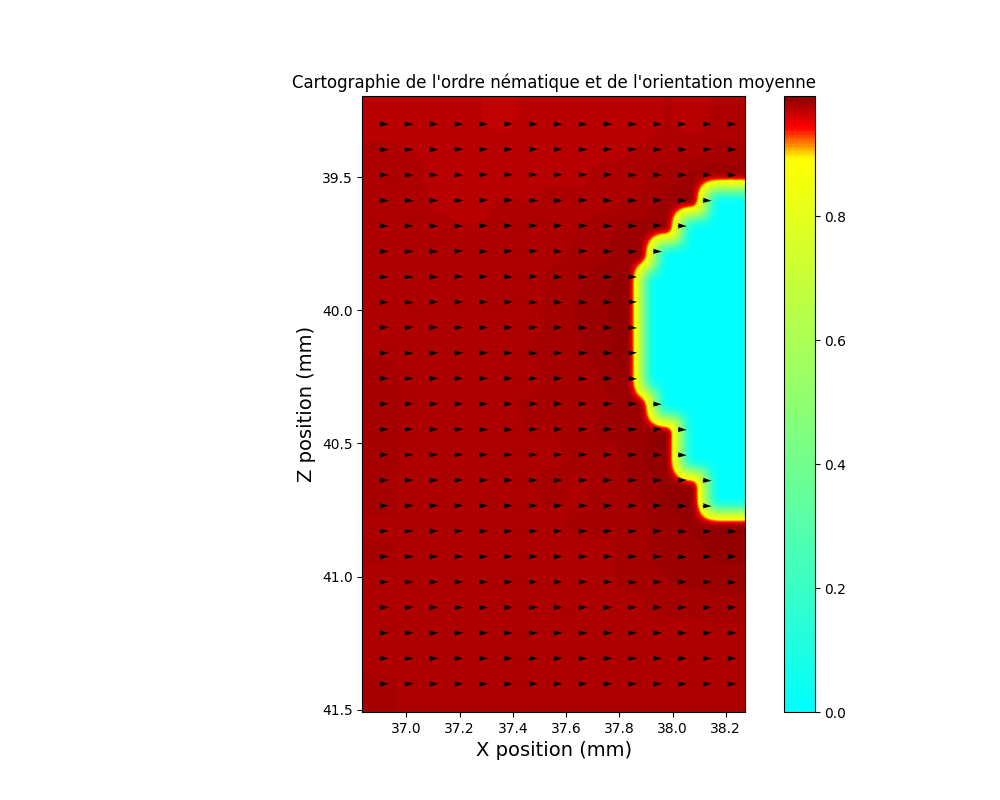

In [26]:

x_2d, z_2d, orientation_2d, S_2d, R2_2d = compute_nematic_order_assembly_SWING(
    h5path=str(testfile.parent),
    mask=mask,
    filelist=sorted_files,
    autosubstract=False,
    reference_file = refmil, 
    qvalue=peaklist[0], 
    threshold=0.05,
    radius = radius,
    L = L,
    radius_pd = radius_pd,
    L_pd= L_pd,
    plot=True,
    apply_mirror=False,
    verbose=True,
    nb_ligne=file.data.shape[1],  # A integrer proprement dans la fonction
    nb_colonne=file.data.shape[0]
    )

## Batch function

All these steps have been wrapped up in a single function "global_analyis", that could be further used for batch analysis. 
This function takes a total of 31 arguments, decomposed as follows:
- 1 arg for csv_file path where results are stored (csv_file)
- 2 args to define the list of files to be analyzed (h5path, prefix='lacroix')
- 4 args to initialize SAXSProcessor instance (mask, referencefile=None, k=1, autosubstract=True)
- 17 args(!) to initialize the hybrid method for correlation distance calculation. (mandatory ones: nb_peaks, qmin, qmax -- other parameters can keep their default value as a start)
- 5 args for nematic order calculation (radius, L, radius_pd, L_pd, threshold) - mostly used for form factor calculation
- 2 args for output (plot, verbose)

SUMMARY: There are 10 mandatory arguments:
- csv_file: path to file where results are appended
- h5path: path to data directory
- mask: path to mask file (pyfai edf format)
- nb_peaks: number of peaks for correlation distance determination
- qmin (=0.01) - qmax (=0.15): fitting window for correlation distance determination
- Form factor parameters (radius, L, radius_pd, L_pd)

In [ ]:
excel_file = "Run_synchrotron_SOLEIL_02_2026_suivi_manips.xlsm" # path to the excel file containing the parameters 
pathh5 = 'test_data/SWING_fev2026/example_emma_rods/test' # path to the folder containing the h5 files (probably the same as bg_path)
mask = "test_data/SWING_fev2026/mask_pyfai_nico.edf" # mask generated by Nicolas directly (edf format)
csv_results_path = os.path.join(pathh5,'analysis_results_batch.csv') # your path
instrument='SWING'

# OLD CODE: not generalized
# If you don't want to use the function that extracts parameters from the excel file (get_all_params), you can directly set your parameters here and run the global analysis:
# results = global_analysis(
#     csv_file=csv_file,
#     h5path=pathh5,
#     reference_file= reference_file, # new param
#     autosubstract=True,
#     mask=mask,
#     nb_peaks=2,
#     qmin=0.02,
#     qmax=0.09,
#     azimuth=90,
#     width=30,
#     method='hybrid',
#     radius=diameter * 10/2, # new param
#     L=length * 10,
#     radius_pd=polydispersity_d * 0.01, # new param
#     L_pd=polydispersity_L * 0.01,
#     plot=False,
#     verbose=False)



# ONGOING WORK: Generalize it more by finding automatically the parameters from the excel file and the h5path 
# Results file will be saved in the same folder as the h5 files, with the name "analysis_results_batch.csv". 
# It will contain the results for all the h5 files in the folder.
from excel_parameters_extractor import get_all_params
results = global_analysis(
    csv_file=csv_results_path,
    h5path=pathh5,
    excel_file=excel_file, # new param
    instrument=instrument,
    autosubstract=True,
    mask=mask,
    nb_peaks=2,
    qmin=0.02,
    qmax=0.09,
    azimuth=90,
    width=30,
    method='hybrid',
    # in the case you use the excel to find it automatically, you can set radius and L to None, and it will be done in the function using the get_all_params function
    radius= None, 
    L= None,
    plot=False,
    verbose=False)



### **NEW: Make a final dataframe with all the parameters for a measurement**

The function **final_dataframe(h5path, excel_file, csv_results_path)** creates a dataframe with all the parameters from the excel file and the csv results (d, S) for all the h5 files in a folder.

How?: It concatenates the two sheets *SAMPLES* and *MEASUREMENTS* from the excel file with the results from the csv file.
    
**Parameters**:

- *h5path* : str, path of the h5 folder 
- *excel_file* : str, path of the excel file containing the experiment informations
- *csv_results_path*: str, path of the csv file containing the results

**Notes**:
- 1. The indexes of the h5 files must be in *FILE* column in *MEASUREMENTS* sheet of the excel file. 
For example: for file *lacroix_00782_2024-07-20_02-32-08.h5*, it must be written as "00782" in the "FILE" column of the excel.
- 2. Should work with the current format of results CSV, with the column *samplename* containing the name of the measurement as "S0001_M0001"
- 3. Uses 2 peaks by default, maybe not the best (verify the impact of this parameter)

In [ ]:
from excel_parameters_extractor import  final_dataframe

excel_file = "Run_synchrotron_SOLEIL_02_2026_suivi_manips.xlsm" # path to the excel file containing the parameters 
pathh5 = "test_data/SWING_fev2026/example_emma_rods/test" # your path
csv_results_path = os.path.join(pathh5,'analysis_results.csv') # your path

dataframe = final_dataframe(pathh5, excel_file, csv_results_path)

In [ ]:
dataframe.head()

In [ ]:
print("Value of the magnetic field for the first measurement is",dataframe['VALUE [mT]'].iloc[0], "mT") 